# Utforske data


In [1]:
import os
import random
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight
import kagglehub

/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
#Laster ned datasettet
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
# Definerer hovedmappe for data
data_path = os.path.join(dataset_path, "Data")

#Lager paths til de forskjellige datasettene
train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

#Se innholdet i mappene
print("Data path:", data_path)
print()
print("TRAIN:", os.listdir(train_path))
print("VALID:", os.listdir(valid_path))
print("TEST:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

TRAIN: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
VALID: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
TEST: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


### OBS

Datasettet er inkonsistent. Train og Valid har like navn, men Testsettet har en forkortelse på navnene.

In [4]:
# Definerer en fast og konsistent rekkefølge på klassene

long_class_names = [
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

print(long_class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [5]:
#Mapper kort til langt navn slik at alle datasettene bruker likt navn!
test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

In [6]:
#lager path til ny mappe
test_fixed_path = os.path.join(data_path, "test_fixed")

#sletter mappen hvis den finnes fra før
if os.path.exists(test_fixed_path):
    shutil.rmtree(test_fixed_path)

#lager ny tom mappe
os.makedirs(test_fixed_path)


#looper gjennom mappingen vi lagde over
for short_name, long_name in test_to_train_name_map.items():
    #lager paths til source og destination
    src = os.path.join(test_path, short_name)
    dst = os.path.join(test_fixed_path, long_name)
    shutil.copytree(src, dst)

#nå skal alle dataene ha samme (lange) navn
print("Ny testnavn:", os.listdir(test_fixed_path))

Ny testnavn: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [7]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_raw = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_fixed_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-22 09:51:28.142823: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-22 09:51:28.142854: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-22 09:51:28.142862: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-22 09:51:28.142880: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-22 09:51:28.142895: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print("Train classes:", train_raw.class_names)
print("Valid classes:", valid_raw.class_names)
print("Test classes:", test_raw.class_names)

Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

def normalize_dataset(ds):
    ds = ds.map(lambda img, label: (normalization_layer(img), label), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_data = normalize_dataset(train_raw)
valid_data = normalize_dataset(valid_raw)
test_data = normalize_dataset(test_raw)

In [10]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 256, 256, 3)
Label batch shape: (32,)
First 10 labels: [3 1 3 2 3 0 0 0 0 3]


2026-04-22 09:51:28.314271: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


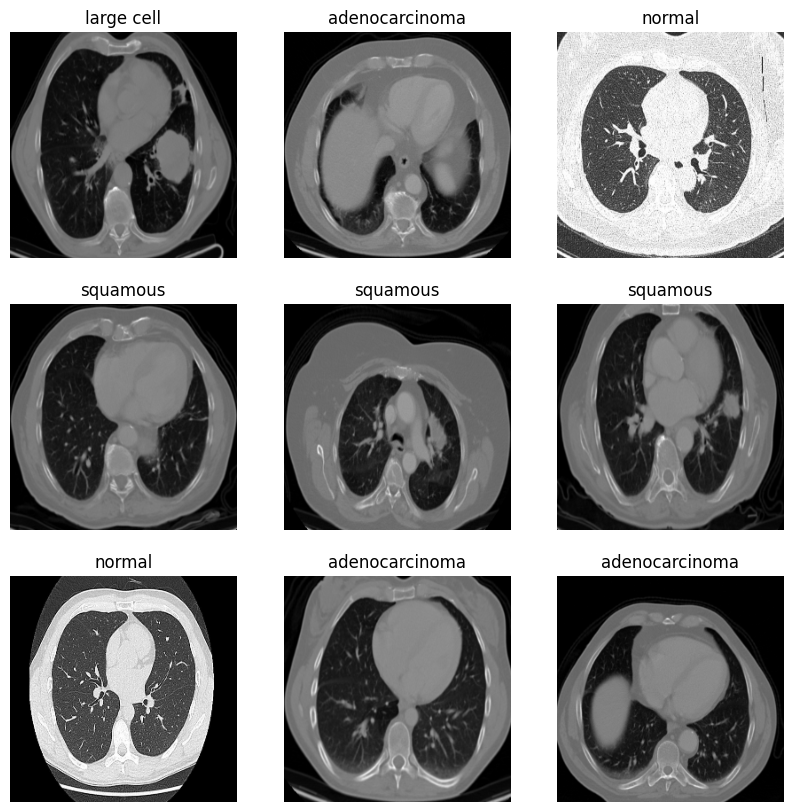

2026-04-22 09:51:28.638045: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
#navnene er veldig lange -> plottene ser dårlig ut
#lager forkortelser
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_names[labels[i]])
        plt.axis("off")
    plt.show()

In [12]:
#14
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_fixed_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120, 'normal': 54, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51}


In [13]:
def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)

    return np.array(y_true), np.array(y_pred)

In [14]:
def evaluate_model(model, dataset, model_name="Model", print_report=True):
    y_true, y_pred = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

    if print_report:
        print(f"evaluation for: {model_name}")
        print(json.dumps(results, indent=2))
        print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

    return results, y_true, y_pred

In [15]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
    disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_history(history):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Train accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

Modellering
--

Commonsense baseline
--

Vi ville ha en baseline modell som vi kan prøve å forbedre med mer avanserte modelle. Vi bruker en majoritetsklasse-modell som alltid predikerer den mest vanlige klassen i treningssettet. I koden over kan vi se at adenocarcinoma er den største klassen i treningsdata. I koden under kan vi se at adenocarcinoma er i index 0, vi kan bruke dette til å se hvilke accuracy vi kan få hvis vi kun tipper adenocarcinoma. Med denne "commonsense" modellen får vi en baseline på 38% accuracy.

Baseline validation accuracy: 0.3194444444444444
                precision    recall  f1-score   support

adenocarcinoma       0.32      1.00      0.48        23
    large cell       0.00      0.00      0.00        21
        normal       0.00      0.00      0.00        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.32        72
     macro avg       0.08      0.25      0.12        72
  weighted avg       0.10      0.32      0.15        72



2026-04-22 09:51:28.777086: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


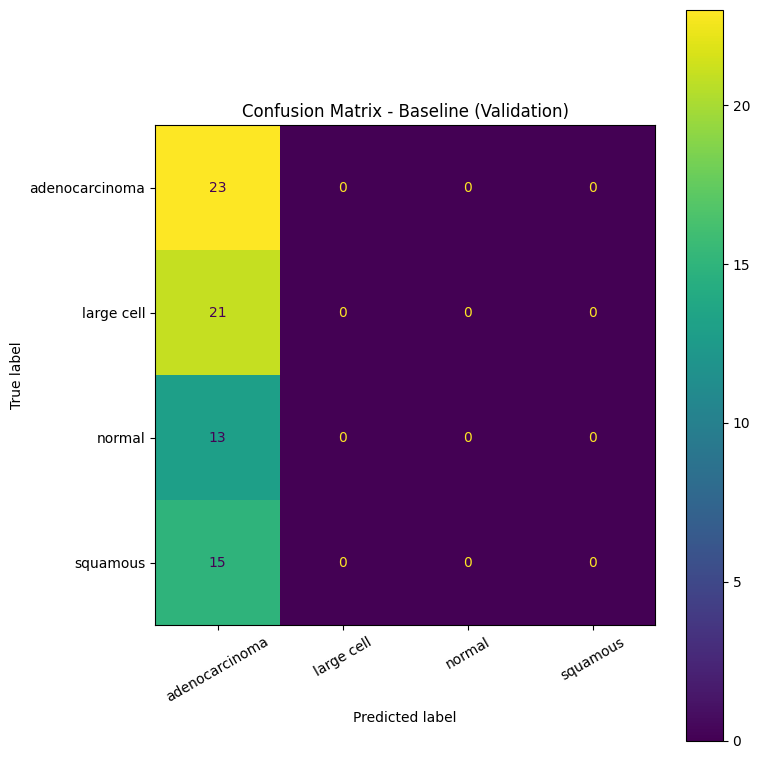

In [17]:
majority_class = 0

labels_true = []

for img, label in valid_data:
    labels_true.extend(label.numpy())

labels_true = np.array(labels_true)
labels_pred = np.full_like(labels_true, fill_value=majority_class)

print("Baseline validation accuracy:", accuracy_score(labels_true, labels_pred))
print(classification_report(labels_true, labels_pred, target_names=display_names, zero_division=0))
plot_confusion(labels_true, labels_pred, "Confusion Matrix - Baseline (Validation)")

Simple dens layer neural network
--

In [18]:
ff_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,175,316 (96.04 MB)

 Trainable params: 25,175,316 (96.04 MB)

 Non-trainable params: 0 (0.00 B)

ff_network summaty:
--
flatten: gjør vår input 128 * 128 * 3 om til en lang liset med tall = 49152.
første dense laget: (input_features × neurons) + bias = 3,145,792
andre dense laget: 64 * 16 + 16 = 1,040
siste dense laget: 16 * 4 + 4 = 68

In [19]:
ff_network.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [20]:
history_ff = ff_network.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10


2026-04-22 09:51:29.265477: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2741 - loss: 142.2175 - val_accuracy: 0.2222 - val_loss: 215.3406
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3051 - loss: 198.4704 - val_accuracy: 0.3194 - val_loss: 552.8026
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3148 - loss: 524.2679 - val_accuracy: 0.1528 - val_loss: 359.3746
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3491 - loss: 156.7576 - val_accuracy: 0.2361 - val_loss: 220.9538
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3573 - loss: 93.3406 - val_accuracy: 0.2917 - val_loss: 69.3055
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3801 - loss: 53.2233 - val_accuracy: 0.3333 - val_loss: 63.5517
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4372 - loss: 35.4714 - val_accuracy: 0.3333 - val_loss: 53.8744
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4796 - loss: 30.1062 - val_accuracy

In [21]:
score = ff_network.evaluate(valid_data, verbose=0)

print("loss:", score[0])
print("Accuracy of the model was {}%".format(score[1]*100))

loss: 48.638790130615234
Accuracy of the model was 30.55555522441864%


evaluation for: FFNN - validation
{
  "model": "FFNN - validation",
  "accuracy": 0.3055555555555556,
  "precision_macro": 0.3087701612903226,
  "recall_macro": 0.3430482560917344,
  "f1_macro": 0.29889236196842156,
  "f1_weighted": 0.2785476602389241
}
                precision    recall  f1-score   support

adenocarcinoma       0.20      0.13      0.16        23
    large cell       0.40      0.19      0.26        21
        normal       0.31      0.38      0.34        13
      squamous       0.32      0.67      0.43        15

      accuracy                           0.31        72
     macro avg       0.31      0.34      0.30        72
  weighted avg       0.30      0.31      0.28        72



2026-04-22 09:51:38.174719: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


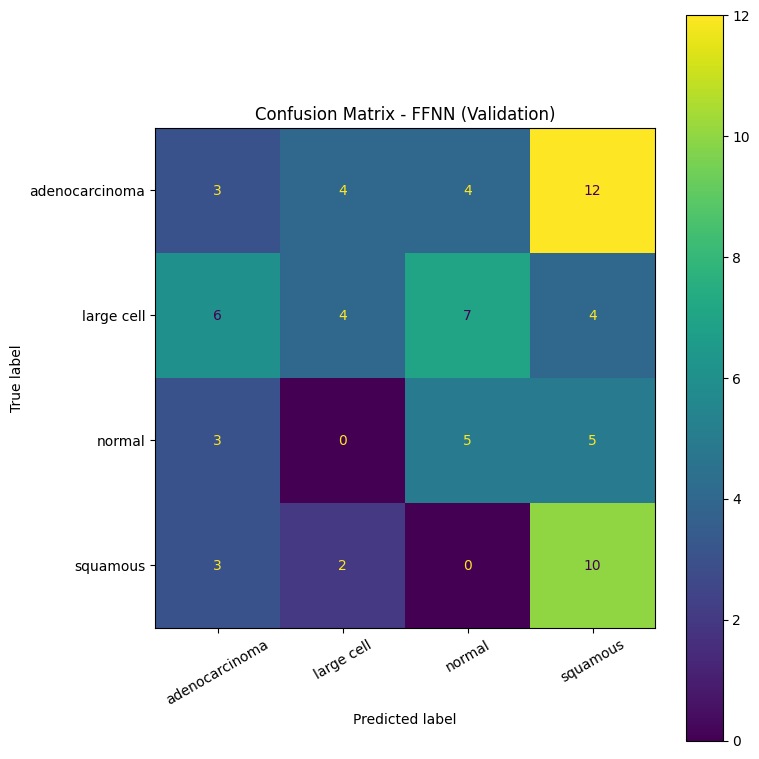

In [22]:
#30
ff_results, y_true_ff, y_pred_ff = evaluate_model(
    ff_network,
    valid_data,
    model_name="FFNN - validation"
)

plot_confusion(y_true_ff, y_pred_ff, "Confusion Matrix - FFNN (Validation)")

Vi kan tydlig se at modellen vår ikke er god nok. Vi kan videre undersøke hvordan modellen fungerer.

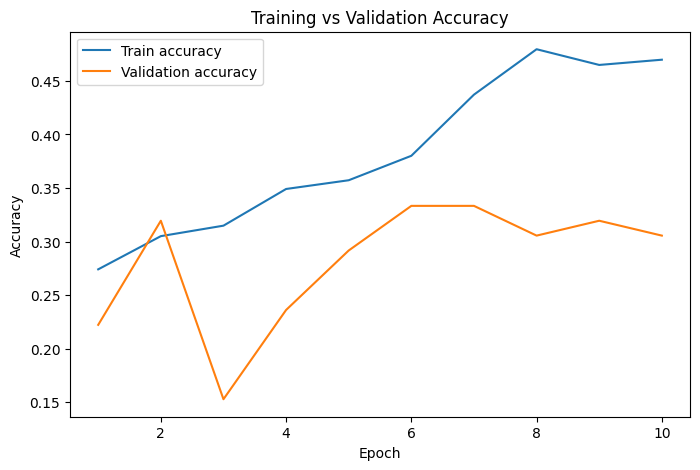

In [23]:
import matplotlib.pyplot as plt

train_acc = history_ff.history["accuracy"]
val_acc = history_ff.history["val_accuracy"]
train_loss = history_ff.history["loss"]
val_loss = history_ff.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

Tolkning av graf
--


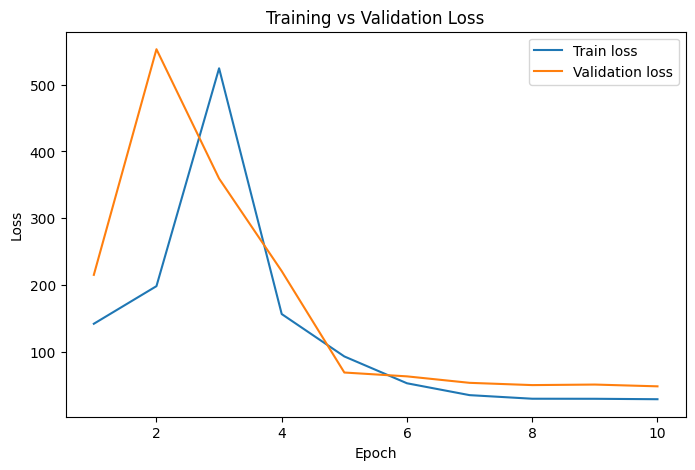

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Modellen lærer veldig fort mellom epoche 1 - 3.
mellom epoche 2-4 ligger kruvene veldig nær hverandre. modellen generaliserer bra. 
Epoche 7-10 begynner validationloss å flate ut også stige litt. Trainingloss fortsetter ganske flatt, dette kan tyde på overfitting.

Tolkning av Confusion Matrix
--
Modellen hadde totalt 8+5+50+60 = 123 riktige predikasjoner av totalt 310 observasjoner. Dette betyr en accuracy på 123/310 = 40%, dette bekrefter at modellen presterer svakt sammenlignet med vår baseline på 38%.

Ved nærmere analyse av confusion matrixen ser vi tydlige svakheter i klassifiseringen av enkelte klasser. Spesielt gjelder dette adenocarcinoma, hvor modellen kun klassifiserte 8 riktige av 120 tilfeller, og 80 tilfeller ble klassifisert som squamous og 32 som normal. Detter viser at modellen i litne grad klarer å skille adenocarcinoma fra de andre klassene.

Modellen klarer i nesten alle tilfeller å predikerer normal, med 50 riktige av 54 tillfeller, og modellen gjøre det relativt greit på aquamous med 60 riktige. Dette tyder på en skjevhet (bias) i modellen hvor den har en tendens til å velge disse klassene.

En slik bias er spesielt problematisk i en medisinsk kontekst, hvor det innebærer at kreftseller blir i noen tilfeller klassifisert som normal

Vi kan se om datasettet kan være en av grunnene for at modellen gjør det så dårlig:

In [25]:
print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Vi kan tydlig se at large cell er den klassen med minst treningssamples. Dette kan forklare grunnen for at modellen ikke klarer å lære gode mønstre for denne klassen. 
Samtidig ser vi at testsettet inneholder 120 tilfeller av adenocarcinoma, men modellen klarer kun å klassifisere 8 riktig. Dette kan tyde på at datasettet ikke er det eneste problemet, men at modellen ikke klarer å fange opp mønstre i dataen. Dette er forventet i en feedforward modell som ser bilder som en flatten liste med tall.

Data agumentation and rescaling
--
Vi kan prøve å fikse problemet med lite data ved hjelp av agumentation:

In [26]:
#model2
#40

data_augmentation_ff = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.2)
])

ff_network_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    data_augmentation_ff,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,175,316 (96.04 MB)

 Trainable params: 25,175,316 (96.04 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
ff_network_aug.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [28]:
history_ff_aug = ff_network_aug.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.3034 - loss: 280.2708 - val_accuracy: 0.1528 - val_loss: 244.1397
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3051 - loss: 309.4771 - val_accuracy: 0.2917 - val_loss: 131.0221
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.2936 - loss: 354.3427 - val_accuracy: 0.3750 - val_loss: 249.9642
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.2838 - loss: 354.4921 - val_accuracy: 0.3611 - val_loss: 63.4220
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2904 - loss: 342.9216 - val_accuracy: 0.1944 - val_loss: 150.6364
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2708 - loss: 364.0888 - val_accuracy: 0.3472 - val_loss: 102.4536
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.2806 - loss: 380.7951 - val_accuracy: 0.3333 - val_loss: 98.9072
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.2773 - loss: 396.302

In [29]:
score = ff_network_aug.evaluate(valid_data, verbose=0)

print("Valid loss:", score[0])
print("Valid accuracy:", score[1])

Valid loss: 66.7616958618164
Valid accuracy: 0.2916666567325592


evaluation for: FFNN + augmentation - validation
{
  "model": "FFNN + augmentation - validation",
  "accuracy": 0.2916666666666667,
  "precision_macro": 0.3894230769230769,
  "recall_macro": 0.36471571906354516,
  "f1_macro": 0.22083333333333333,
  "f1_weighted": 0.1834104938271605
}
                precision    recall  f1-score   support

adenocarcinoma       1.00      0.04      0.08        23
    large cell       0.00      0.00      0.00        21
        normal       0.25      0.62      0.36        13
      squamous       0.31      0.80      0.44        15

      accuracy                           0.29        72
     macro avg       0.39      0.36      0.22        72
  weighted avg       0.43      0.29      0.18        72



2026-04-22 09:51:55.307705: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


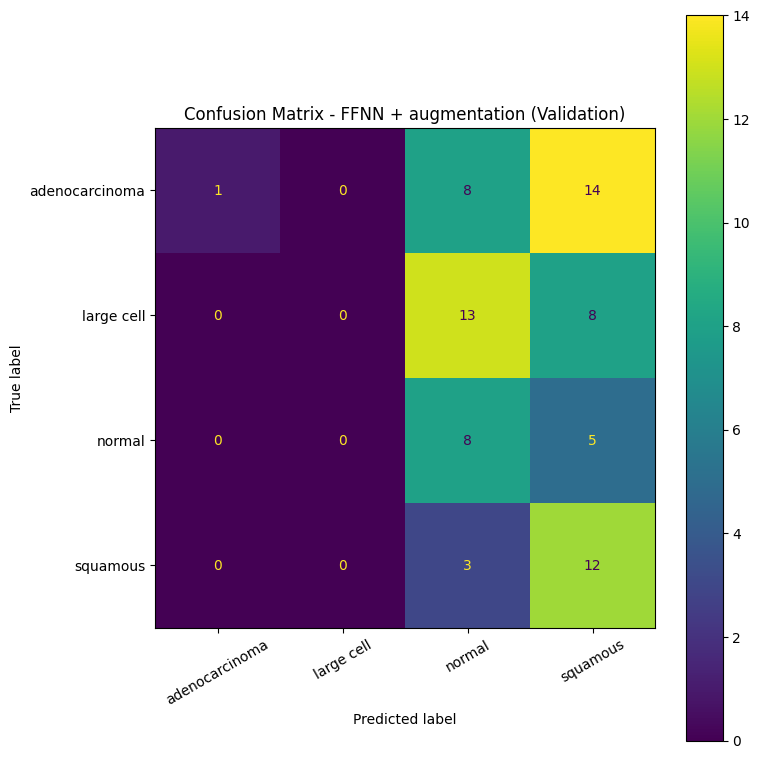

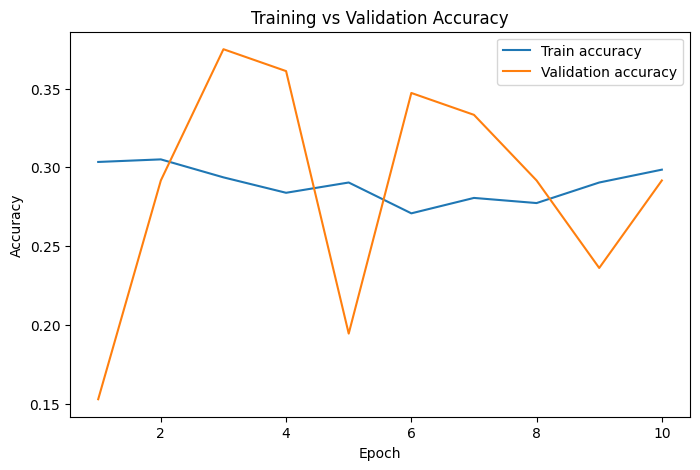

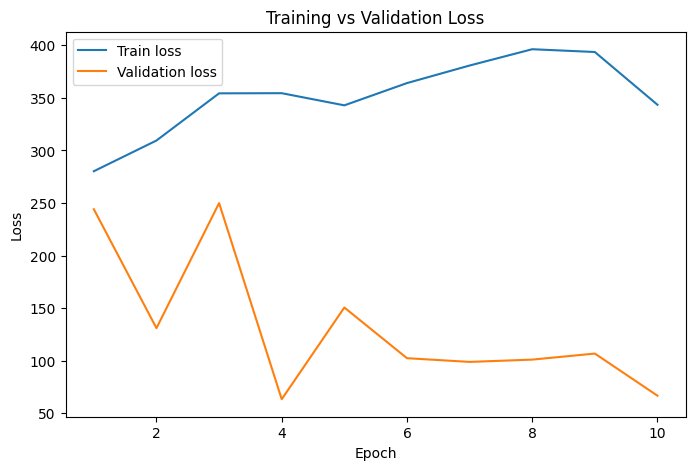

In [30]:
ff_aug_results, y_true_ff_aug, y_pred_ff_aug = evaluate_model(
    ff_network_aug,
    valid_data,
    model_name="FFNN + augmentation - validation"
)

plot_confusion(y_true_ff_aug, y_pred_ff_aug, "Confusion Matrix - FFNN + augmentation (Validation)")
plot_history(history_ff_aug)

Konklusjon av FFNN:
--
Med omfattende testing og analyse ser vi at resultatene fra FFNN-modelen ikke er pålitlige nok til å kunne trekke en konklusjon. Modellen er for enkel, og datasettet er for lite til at modellen kunne lære mønstre. Vi observerte også stor variasjon (+- 15%) mellom kjøring av samme kode på forskjellige seed, noe som tyder på at en mer avanser modell må tas i bruk.

Prøver en CNN modell
--

In [31]:
#model3
simple_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256,256,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [32]:
simple_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,972 (2.64 MB)

 Trainable params: 691,972 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_simple_cnn = simple_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.3034 - loss: 1.3368 - val_accuracy: 0.1806 - val_loss: 1.2665
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.4192 - loss: 1.1837 - val_accuracy: 0.5000 - val_loss: 1.1392
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5041 - loss: 1.1451 - val_accuracy: 0.5000 - val_loss: 1.1188
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5090 - loss: 1.0966 - val_accuracy: 0.3333 - val_loss: 1.2092
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.4894 - loss: 1.1394 - val_accuracy: 0.5000 - val_loss: 1.0804
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.4796 - loss: 1.1187 - val_accuracy: 0.4583 - val_loss: 1.0694
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5220 - loss: 1.0378 - val_accuracy: 0.5000 - val_loss: 1.0134
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.4763 - loss: 1.1400 - val_accuracy: 0.500

In [34]:
#50
valid_loss, valid_acc = simple_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Validation loss: 0.9707100987434387
Validation accuracy: 0.375


evaluation for: CNN from scratch - validation
{
  "model": "CNN from scratch - validation",
  "accuracy": 0.375,
  "precision_macro": 0.3791208791208791,
  "recall_macro": 0.4717391304347826,
  "f1_macro": 0.37288557213930346,
  "f1_weighted": 0.29777501381978994
}
                precision    recall  f1-score   support

adenocarcinoma       0.29      0.09      0.13        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      1.00      1.00        13
      squamous       0.23      0.80      0.36        15

      accuracy                           0.38        72
     macro avg       0.38      0.47      0.37        72
  weighted avg       0.32      0.38      0.30        72



2026-04-22 09:52:32.518050: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


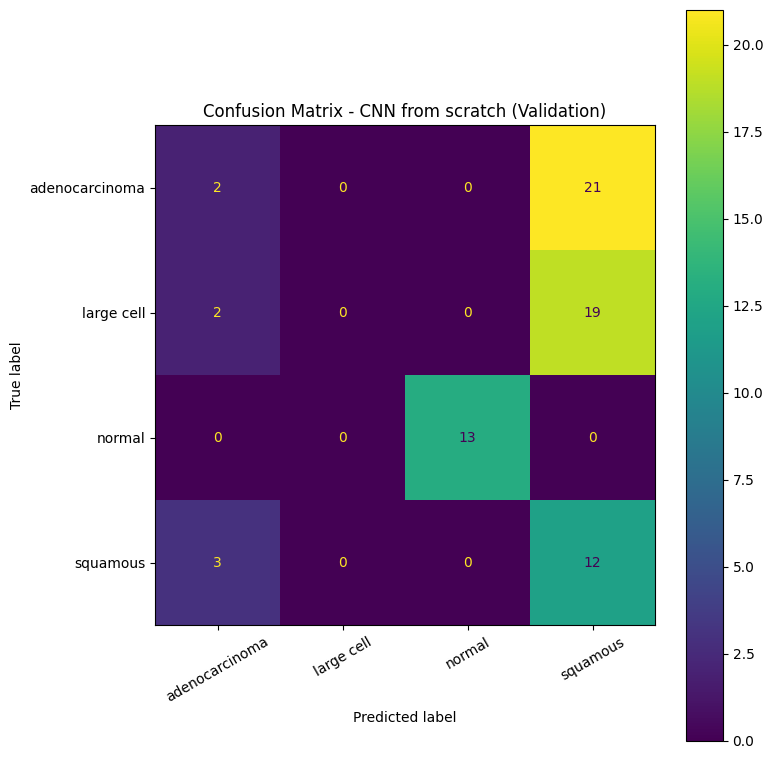

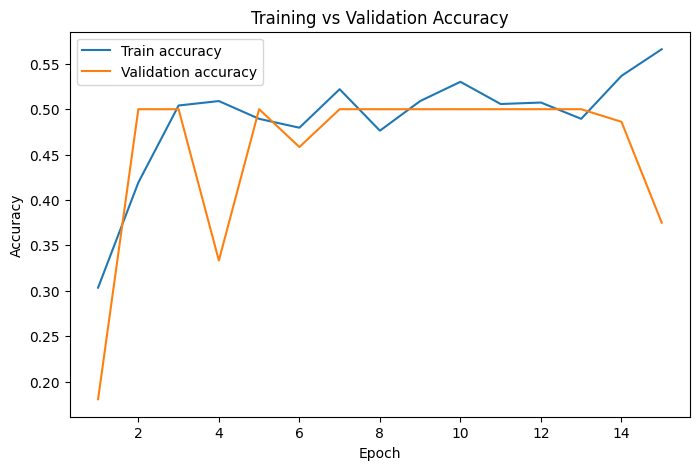

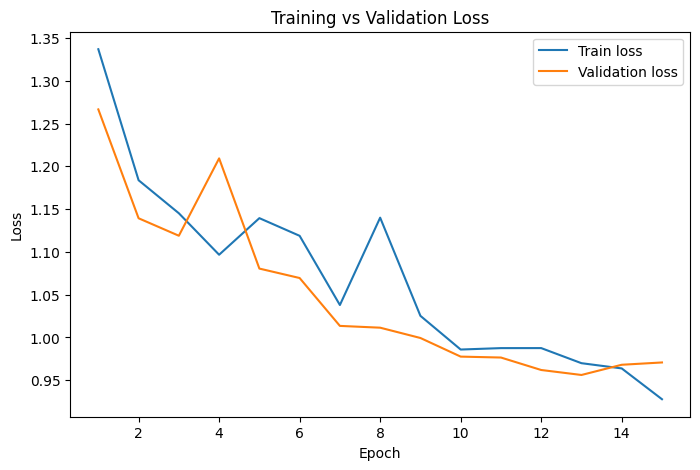

In [35]:
simple_cnn_results, y_true_simple_cnn, y_pred_simple_cnn = evaluate_model(
    simple_cnn_model,
    valid_data,
    model_name="CNN from scratch - validation"
)

plot_confusion(y_true_simple_cnn, y_pred_simple_cnn, "Confusion Matrix - CNN from scratch (Validation)")
plot_history(history_simple_cnn)

Tolkning av graf
--
Train accuracy går opp, noe som viser at modellen lærer. modellen finner mønster i data. Modellen er robust, validation holder seg stabil. Vi ser ingen tegn til overfitting, og det er bra generelt, men vi vil først ha en modell som overfitter for å deretter endre modellen til at den ikke overfitter.

Vi kan endre modellen slik at den overfitter:

In [36]:
#model4
#54
larger_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(4, activation="softmax")
])

In [37]:
larger_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

larger_cnn_model.summary()

history_larger_cnn = larger_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

valid_loss, valid_acc = larger_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,228 (1.54 MB)

 Trainable params: 404,228 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.2757 - loss: 1.3408 - val_accuracy: 0.1806 - val_loss: 1.3783
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.3801 - loss: 1.2576 - val_accuracy: 0.3889 - val_loss: 1.2201
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.4829 - loss: 1.1330 - val_accuracy: 0.4861 - val_loss: 1.0410
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.4649 - loss: 1.1050 - val_accuracy: 0.5000 - val_loss: 1.0533
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.5008 - loss: 1.0585 - val_accuracy: 0.5000 - val_loss: 1.0110
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.5204 - loss: 1.0115 - val_accuracy: 0.3611 - val_loss: 1.0344
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.4943 - loss: 1.0484 - val_accuracy: 0.4861 - val_loss: 0.9898
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.5351 - loss: 0.9830 - val_accuracy: 0.

evaluation for: Larger CNN - validation
{
  "model": "Larger CNN - validation",
  "accuracy": 0.4444444444444444,
  "precision_macro": 0.38425925925925924,
  "recall_macro": 0.4455964325529543,
  "f1_macro": 0.3828463203463204,
  "f1_weighted": 0.35129569504569497
}
                precision    recall  f1-score   support

adenocarcinoma       0.37      0.87      0.52        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      0.85      0.92        13
      squamous       0.17      0.07      0.10        15

      accuracy                           0.44        72
     macro avg       0.38      0.45      0.38        72
  weighted avg       0.33      0.44      0.35        72



2026-04-22 09:53:51.039279: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


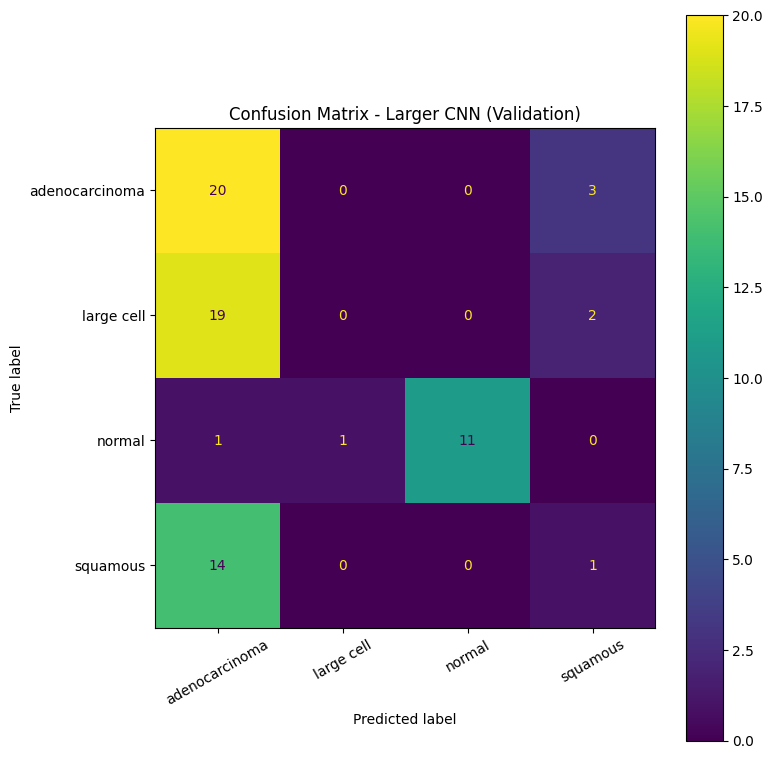

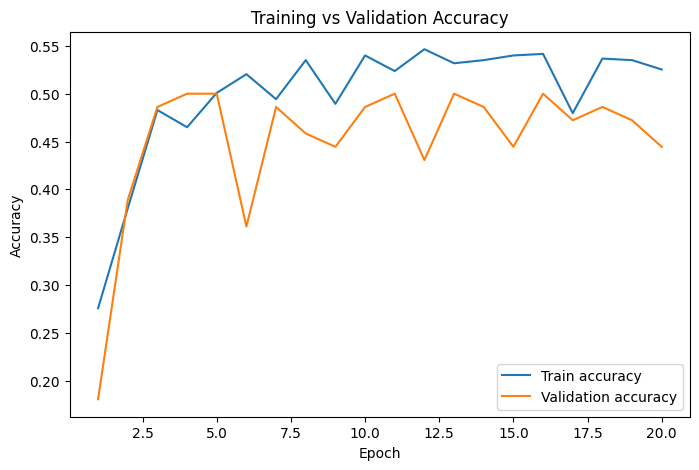

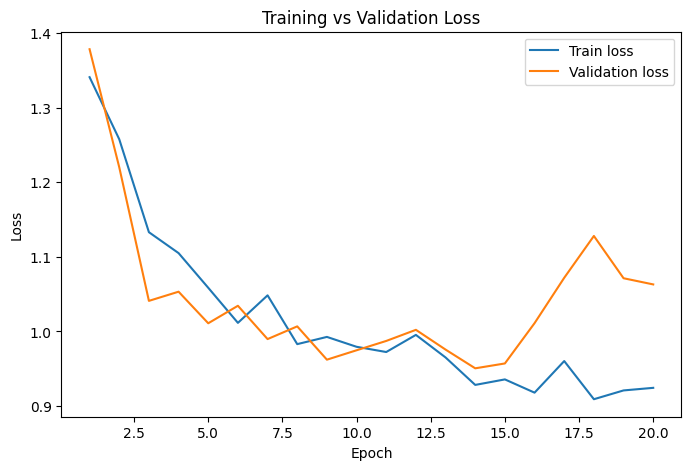

In [38]:
larger_cnn_results, y_true_larger_cnn, y_pred_larger_cnn = evaluate_model(
    larger_cnn_model,
    valid_data,
    model_name="Larger CNN - validation"
)

plot_confusion(y_true_larger_cnn, y_pred_larger_cnn, "Confusion Matrix - Larger CNN (Validation)")
plot_history(history_larger_cnn)

Tolkning av graf
--
Vi kan se at traing accuract går jevnt opp, dette tyder på at modellen lærer. Train accuracy er er over validation accuracy store deler av epokene, noe som tyder på mild overfitting. dette er bra, det var det vi ville oppnå. Begge loss minker, men etter epoke 16 øker validation loss. Dette kan være et tegn på at overfitting begynner. Ut i fra det vi har tolket fra grafene, kan vi lage en forbedret modell

Forbedring:
Vi kan legge til data augmentation. Grafene viser at modellen lærte treningsdata bedre enne valideringsdata. det kan tyde på at modellen begynte å bli for god på treningssettet, da vil augmentation hjelpe med å modellen flere varianter av samme bilde, redusere overfitting og gjøre modellen mer robust. 
Modellen var ganske kraftig med 64 - 128 - 256, vi kan endre dette til 32 - 64 - 128. det er ingenting i grafene som tilsier at modellen er for krafig, så vi kan gjøre den litt mindre. Det vil da føre til at det blir lettere å generalisere på et lite datasett og reduserer overfitting. 
Vi kan legge til padding="same" for å bevare mer informasjon i feature maps.
Vi kan minke litt på dropout. 
Vi kan legge til early stopping. Grafene viser at validation accuracy flater ut ganske tidlig, og validation loss begynner å øke senere, dette tyder på at modellen er best før siste epoke, noe som vi kan fiske med early stopping, som vil stoppe treningen når modellen slutter å bli bedre.
Merk: vi kunne også lagt til cross-validation for å få en mer robust evaluering, men ble ikke brukt siden datasettet hadde en fast test/train/validation - inndeling.

In [39]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1),
])

improved_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

In [ ]:
improved_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_improved_cnn = improved_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=25,
    callbacks=[early_stopping]
)

improved_cnn_model.summary()

valid_loss, valid_acc = improved_cnn_model.evaluate(valid_data, verbose=0)

print("Validation loss:", valid_loss)
print("Validation accuracy:", valid_acc)

Epoch 1/25


In [ ]:
improved_cnn_results, y_true_improved_cnn, y_pred_improved_cnn = evaluate_model(
    improved_cnn_model,
    valid_data,
    model_name="Improved CNN - validation"
)

plot_confusion(y_true_improved_cnn, y_pred_improved_cnn, "Confusion Matrix - Improved CNN (Validation)")
plot_history(history_improved_cnn)

Tolkning av Confusion Matrix
--
Confusion matrixen viser en tydelig skjevhet i predikasjonene, hvor nesten alle tilfellene klassifiseres som adenocarcinoma. Dette fører til at klasser som large cell og squamous nesten aldri blir riktig klassifisert.

Selv om denne modellen har fått klart høyes accuracy, skjuler dne et alvorlig problem hvor modellen ikke klarer å skille mellom flere av klassene. Dette viser at accuracy alene ikke er bra nok som evalueringsmetode.

Forbedring av modellen:
Confusion matrixen viste at modellen hadde en sterk bias mot adenocarcinoma, og at den i liten grad klarte å klassifisere riktig large cell og squamous. For å fikse dette kan vi legge til weights til klassene, slik at feil på underrepresenterte klasser ble straffet hardere under trening. I tillegg legger vi til batch og normalization for å stabilisere læringen og forbedre feature extraction. ReduceLROnPlateau og EarlyStopping brukt for å forbedre treningsstabilitet og generalisering


Transfer learning
--

In [ ]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_for_mobilenet(ds):
    ds = ds.map(lambda x, y: (mobilenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_tl = preprocess_for_mobilenet(train_raw)
valid_tl = preprocess_for_mobilenet(valid_raw)
test_tl = preprocess_for_mobilenet(test_raw)

In [ ]:
data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

pretrained_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation_tl,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pretrained_model.summary()

In [ ]:
history_pretrained = pretrained_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=20
)

score = pretrained_model.evaluate(valid_tl, verbose=0)

print("Validation loss:", score[0])
print("Validation accuracy:", score[1])

pretrained_results, y_true_pretrained, y_pred_pretrained = evaluate_model(
    pretrained_model,
    valid_tl,
    model_name="Transfer learning (frozen base) - validation"
)

plot_confusion(y_true_pretrained, y_pred_pretrained, "Confusion Matrix - Transfer Learning (Validation)")
plot_history(history_pretrained)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_pretrained_finetuned = pretrained_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=10
)

In [ ]:
pretrained_finetuned_results, y_true_pretrained_ft, y_pred_pretrained_ft = evaluate_model(
    pretrained_model,
    valid_tl,
    model_name="Transfer learning (fine-tuned) - validation"
)

plot_confusion(y_true_pretrained_ft, y_pred_pretrained_ft, "Confusion Matrix - Transfer Learning Fine-tuned (Validation)")
plot_history(history_pretrained_finetuned)

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    ff_results,
    ff_aug_results,
    simple_cnn_results,
    larger_cnn_results,
    improved_cnn_results,
    pretrained_results,
    pretrained_finetuned_results
])

results_df = results_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
results_df

In [ ]:
final_model = pretrained_model
final_test_data = test_tl

In [ ]:
final_results, y_true_test, y_pred_test = evaluate_model(
    final_model,
    final_test_data,
    model_name="Final model - test"
)

plot_confusion(y_true_test, y_pred_test, "Confusion Matrix - Final Model (Test)")

In [ ]:
final_model = pretrained_model  
final_model.save("model.keras")